In [8]:
!git clone https://github.com/KaizokuOu56/movingMirror.git

Cloning into 'movingMirror'...
remote: Enumerating objects: 203, done.
remote: Counting objects: 100% (110/110), done.
remote: Compressing objects: 100% (93/93), done.
remote: Total 203 (delta 45), reused 64 (delta 14), pack-reused 93 (from 1)
Receiving objects: 100% (203/203), 175.84 MiB | 21.33 MiB/s, done.
Resolving deltas: 100% (73/73), done.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
save_dir = "/content/drive/MyDrive/movingMirror/experimental_data/trial8"
os.makedirs(save_dir, exist_ok=True)

In [3]:
import numpy as np
N = 50   # grid size

Given that $\alpha_{p\omega}$, $\beta_{p\omega}$ $=$ $\mp$ $\frac{i}{2\pi p\omega}$ $e^{\frac{\pm\pi p}{2 \kappa}}$ $e^{-ipD}$ $e^{\pm i \omega B}$ $\omega ^ {\frac{-ip}{\kappa}}$ $Γ(1 + \frac{ip}{\kappa})$, where $D = \frac{\ln A}{\kappa} - B$,

First making it into an easier to understand form,

$\alpha_{p\omega}$, $\beta_{p\omega}$ $=$ $\mp$ $\frac{i}{2\pi p\omega}$ $e^{\frac{\pm\pi p}{2 \kappa}}$ $e^{-i(pD \, \mp \, \omega B \, + \, \frac{p \ln \omega}{\kappa})}$ $Γ(1 + \frac{ip}{\kappa})$

Now consider $\alpha_{p \omega} = a + ib$, the $p, \omega$ term of $\alpha \_r$ and $\alpha \_ i$ are $a$ and $b$ respectively. A good measure to study how $\alpha$ evolves is by looking at how $\| \alpha_{p \omega}\| = \sqrt{a^2 + b^2}$ appears (same for $\beta_{p \omega}$)

Taking the mod,

$\| \alpha_{p \omega}\|, \| \beta_{p \omega} \|$ $=$ $\frac{e^{\frac{\pm \pi p}{2 \kappa}}}{2 \pi p \omega}$ $\| \Gamma(1 + \frac{ip}{\kappa}) \|$, now $\Gamma(1 + ia) = ia \, \Gamma(ia)$, taking mod,

$\| \Gamma(1 + ia) \| = \sqrt{\frac{\pi a}{sinh(\pi a)}}$, since $a = \frac{p}{\kappa}$, p and $\kappa$ are positive,

$\| \alpha_{p \omega}\|, \| \beta_{p \omega} \|$ $=$ $\frac{e^{\frac{\pm \pi p}{2 \kappa}}}{2 \pi p \omega}$ $\sqrt{\frac{\pi p}{\kappa \, sinh(\frac{\pi p}{\kappa})}}$

So the magnitude only depends on $\kappa$, so plotting for $\kappa = 0.001, 0.01, 0.1, 1, 5, 10, 100 \, \& \, 1000$:

In [4]:
def generate_aOrb_matrix(choice, kappa_, N=N):
  Y = np.zeros((N, N), dtype=np.float64)

  lim = 500
  e = 0.001
  if choice == "alpha":
    for i in range(1, N+1):
      for j in range(1, N+1):
        exp = np.pi * i/(2 * kappa_)
        if exp > lim:
          exp = lim
        sinh = np.pi * i / kappa_
        if sinh > lim:
          sinh = lim

        Y[i-1, j-1] = np.exp(exp) / (2 * np.pi * i * j) * np.sqrt(np.pi * i / (kappa_ * np.sinh(sinh)))
        if Y[i-1, j-1] == 0:
          Y[i-1, j-1] = e
        elif Y[i-1, j-1] > 2:
          Y[i-1, j-1] = 2

  elif choice == "beta":
    for i in range(1, N+1):
      for j in range(1, N+1):
        exp = np.pi * i/(2 * kappa_)
        if exp > lim:
          exp = lim
        sinh = np.pi * i / kappa_
        if sinh > lim:
          sinh = lim

        Y[i-1, j-1] = np.exp(-exp) / (2 * np.pi * i * j) * np.sqrt(np.pi * i / (kappa_ * np.sinh(sinh)))
        if Y[i-1, j-1] == 0:
          Y[i-1, j-1] = e
        elif Y[i-1, j-1] > 2:
          Y[i-1, j-1] = 2

  else:
    raise ValueError("Only alpha or beta allowed")

  return Y

In [ ]:
print(np.sinh(5/0.01))
print(np.exp(5/0.01))

7.017961089264188e+216
1.4035922178528375e+217


* if kappa < 0.01, exp overflow
* if input to sinh ~ 50/0.01, overflow

Hence added limit constraint


In [5]:
kappas = [0.001, 0.01, 0.1, 1, 5, 10, 100, 1000]
Alphas = np.zeros((len(kappas), N, N), dtype=np.float64)
Betas = np.zeros((len(kappas), N, N), dtype=np.float64)

for i, kappa in enumerate(kappas):
  Alphas[i] = generate_aOrb_matrix("alpha", kappa)
  Betas[i] = generate_aOrb_matrix("beta", kappa)

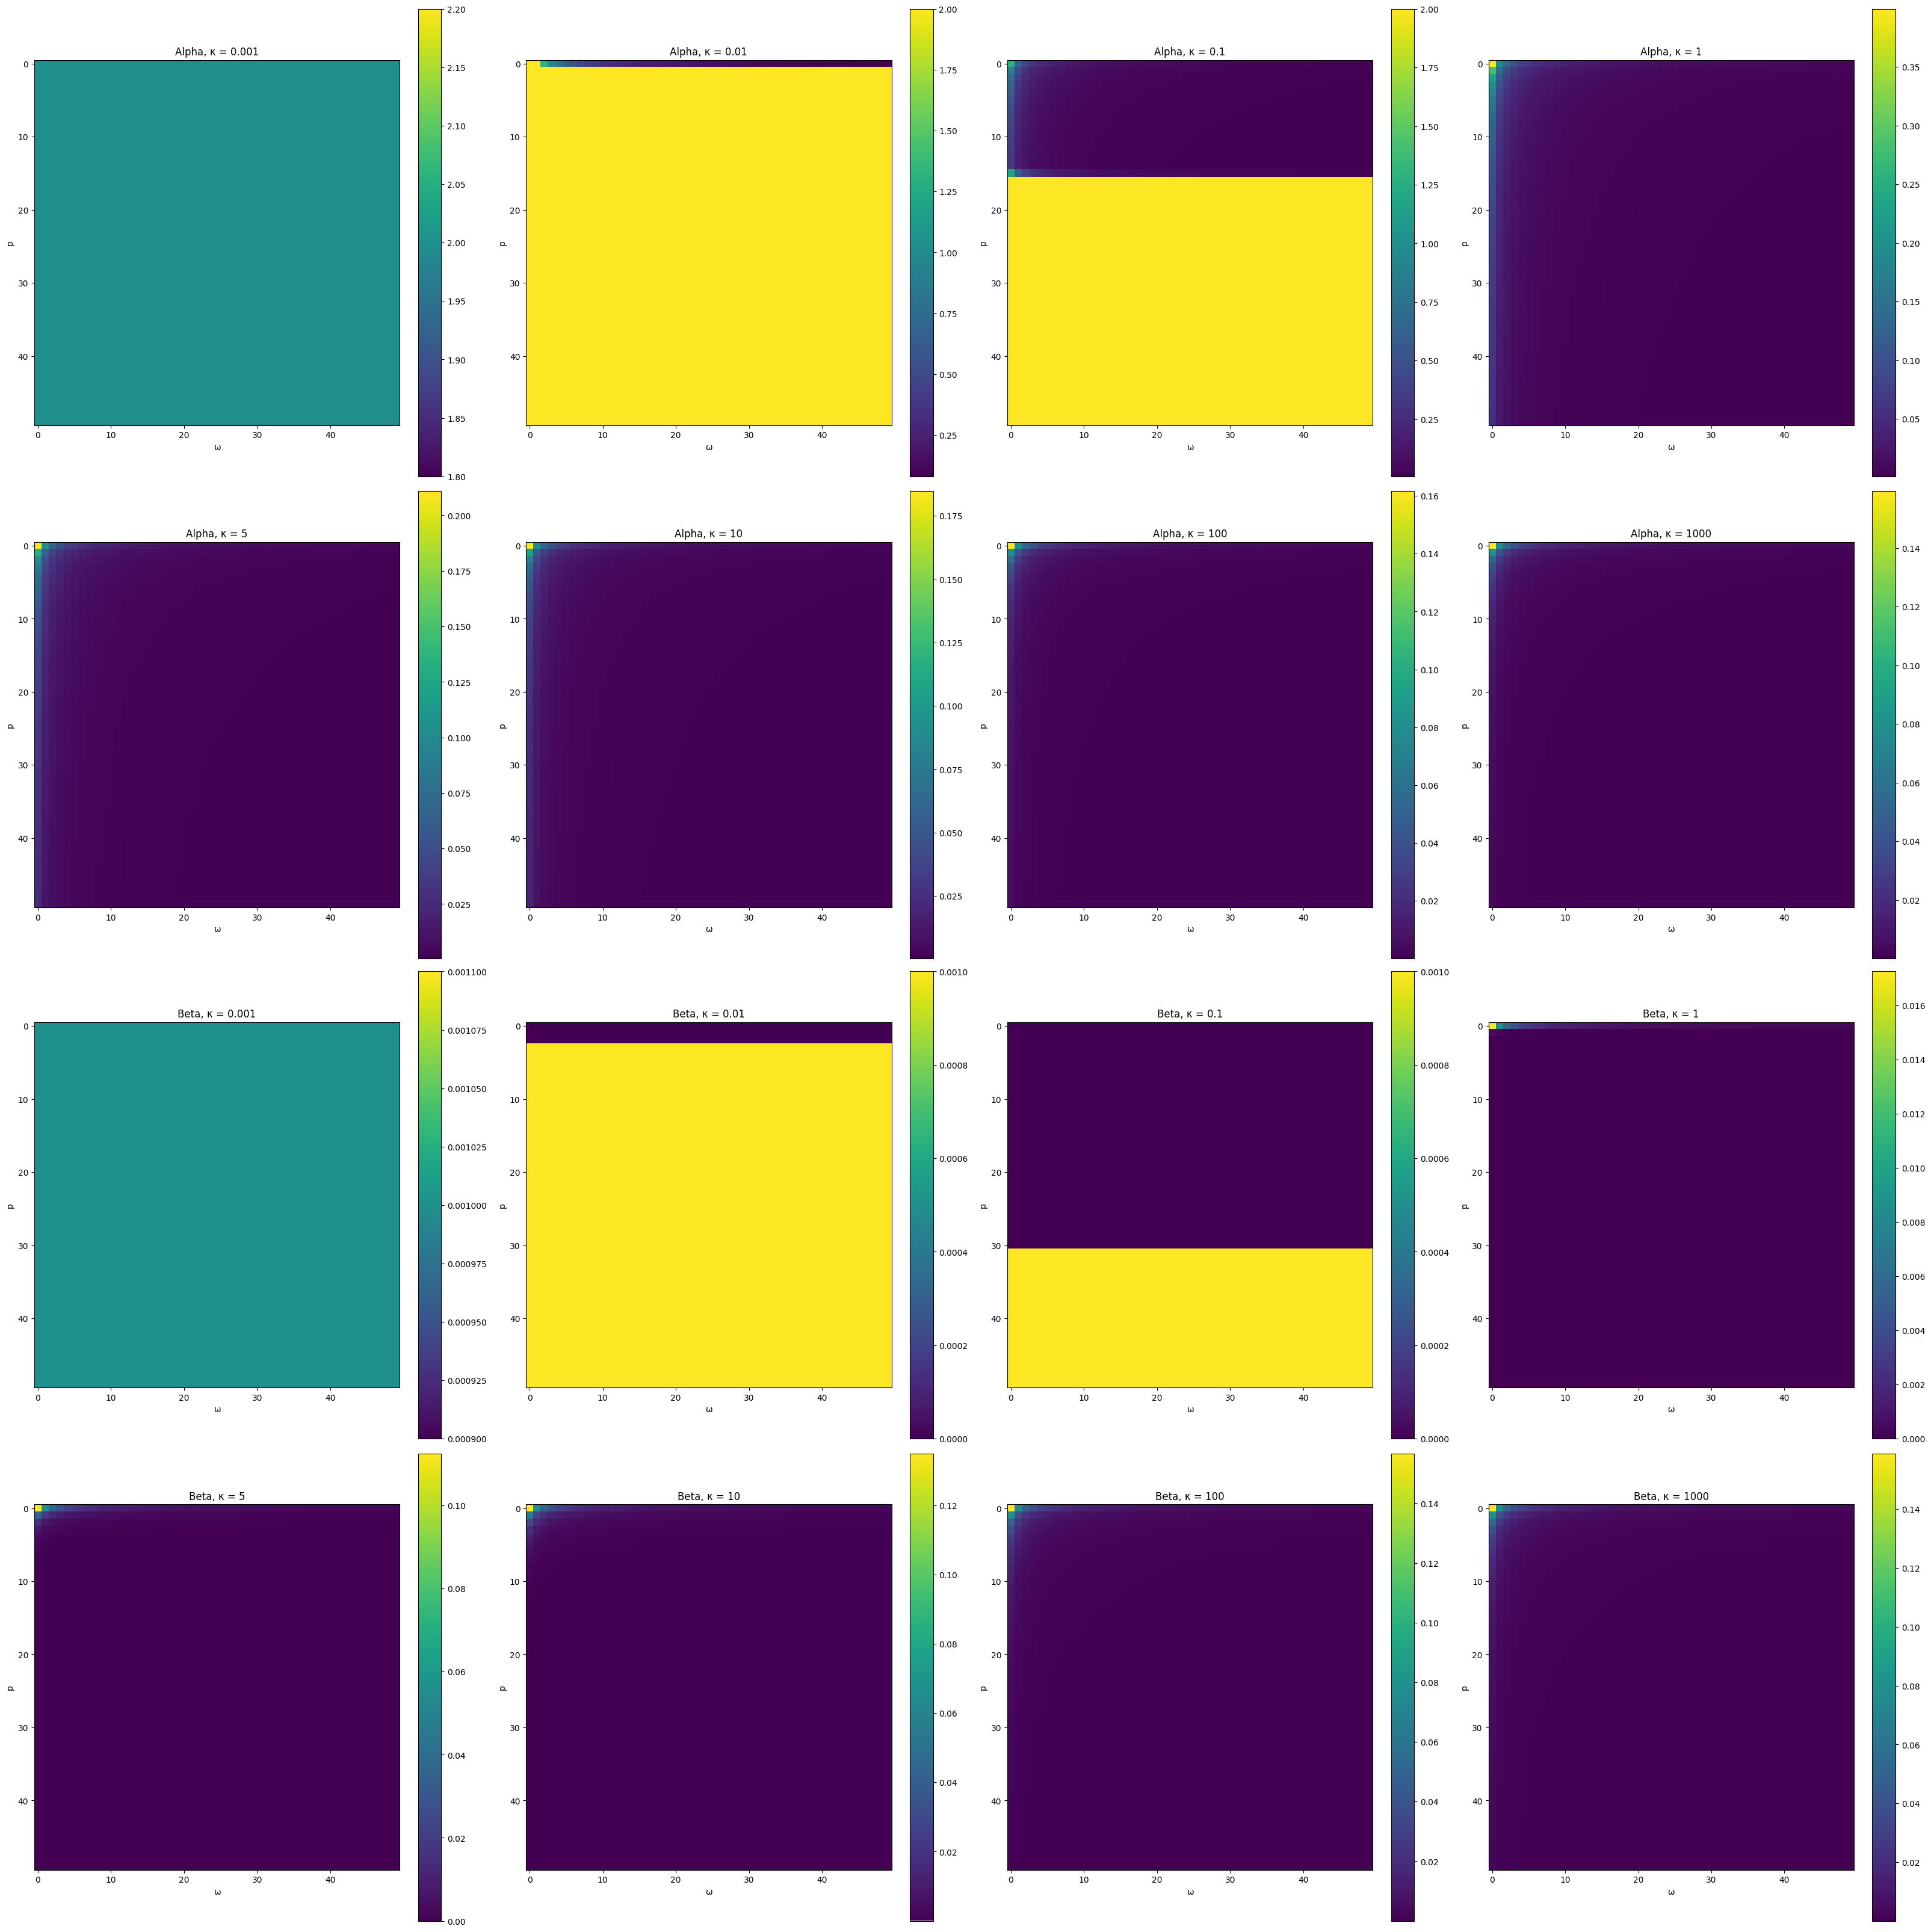

In [7]:
import matplotlib.pyplot as plt
import numpy as np # Import numpy

N_ = len(Alphas)
fig, axes = plt.subplots(
    nrows=4,
    ncols=N_//2,
    figsize=(4 * N_, 4 * N_),
    constrained_layout=True
)

for i, kappa_val in enumerate(kappas):
    # ---------- Alpha ----------
    if(i < N_/2):
      im = axes[0, i].imshow(Alphas[i], aspect='equal', cmap='viridis')
      plt.colorbar(im, ax=axes[0, i])
      axes[0, i].set_title(f'Alpha, κ = {kappa_val}')
      axes[0, i].set_ylabel('p')
      axes[0, i].set_xlabel('ω')
    else:
      im = axes[1, i-4].imshow(Alphas[i], aspect='equal', cmap='viridis')
      plt.colorbar(im, ax=axes[1, i-4])
      axes[1, i-4].set_title(f'Alpha, κ = {kappa_val}')
      axes[1, i-4].set_ylabel('p')
      axes[1, i-4].set_xlabel('ω')

    # ---------- Beta ----------
    if(i < N_/2):
      im = axes[2, i].imshow(Betas[i], aspect='equal', cmap='viridis')
      plt.colorbar(im, ax=axes[2, i])
      axes[2, i].set_title(f'Beta, κ = {kappa_val}')
      axes[2, i].set_ylabel('p')
      axes[2, i].set_xlabel('ω')
    else:
      im = axes[3, i-4].imshow(Betas[i], aspect='equal', cmap='viridis')
      plt.colorbar(im, ax=axes[3, i-4])
      axes[3, i-4].set_title(f'Beta, κ = {kappa_val}')
      axes[3, i-4].set_ylabel('p')
      axes[3, i-4].set_xlabel('ω')

plt.show()

save_path = os.path.join(save_dir, "alphas and betas mod.png")
fig.savefig(save_path, dpi=300, bbox_inches="tight")